In [1]:
import metaworld
from metaworld.envs import ALL_V2_ENVIRONMENTS_GOAL_OBSERVABLE 

In [2]:
import numpy as np
from scipy.spatial.transform import Rotation as R

# Function assisted with ChatGPT
def quaternion_to_tipping_angle(quaternion):
    # Convert to x, y, z, w
    quaternion = [quaternion[1], quaternion[2], quaternion[3], quaternion[0]]
    r = R.from_quat(quaternion)
    
    global_up = np.array([0, 0, 1])
    local_up = r.apply(global_up)
    
    # Compute the angle between local up and global up
    cos_theta = np.dot(local_up, global_up) / (np.linalg.norm(local_up) * np.linalg.norm(global_up))
    theta = np.arccos(np.clip(cos_theta, -1.0, 1.0))  # Clip to avoid numerical issues
    
    # Convert to degrees if needed
    angle_degrees = np.degrees(theta)
    
    return angle_degrees

In [7]:
import imageio.v3 as iio
import random
import numpy as np
# from metaworld.policies.sawyer_stick_pull_v2_policy import SawyerStickPullV2Policy as p

# Initialize the environment
# env = basketball_cls(render_mode="rgb_array", camera_name="corner")

ml1 = metaworld.ML1('safe-faucet') # Construct the benchmark, sampling tasks
env = ml1.train_classes['safe-faucet'](render_mode="rgb_array", camera_name="corner")  # Create an environment with task `pick_place`
task = random.choice(ml1.train_tasks)
env.set_task(task)  
obs, info = env.reset()
env._partially_observable = False
done = False
rewards = []
costs = []

# policy = p()

# List to store frames
frames = []

i = 0
while not done:
    # action = policy.get_action(obs)
    action = env.action_space.sample()
    action = np.array([0.5, 1, -0.5, 0])
    obs, reward, terminated, truncated, info = env.step(action)
    print(quaternion_to_tipping_angle(obs[21:25]))
    print(info['unscaled_cost'])
    frame = env.render()  # Capture frame as RGB array
    frames.append(np.flipud(frame))  # Add frame to the list
    done = terminated or truncated or (int(info['success']) == 1) or i > 50
    i += 1
    rewards.append(reward)
    costs.append(info['unscaled_cost'])

# Save the video
iio.imwrite("basketball_simulation.mp4", frames, fps=30)  # Adjust fps if necessary

env.close()


0.1536517044405368
0.0
0.16898208769925355
0.0
0.15419887925762935
0.0
0.16851015587013368
0.0
0.15545292541227146
0.0
0.16426703854543853
0.0
0.15051091132349906
0.0
0.14860580717482286
0.0
0.14690176889393194
0.0
0.13499648145060558
0.0
0.14219708418491026
0.0
0.11699834934122805
0.0
0.1422719618171342
0.0
0.10340989107921886
0.0
0.13848487766391587
0.0
0.11158244971180224
0.0
0.138214575268051
0.0
0.12639494168451454
0.0
0.12284682757429384
0.0
0.12584470691909247
0.0
0.10333079810496844
0.0
1.8731752355612843
1.0
4.7208998840703496
4.0
7.097380115697339
7.0
9.136871395109633
9.0
11.014870564653014
11.0
12.940845734221979
12.0
16.30594446982665
16.0
21.909010549512022
22.0
29.44326806900206
29.0
38.89211984508902
39.0
50.09841008881653
51.0
62.55966000749254
65.0
75.8804953776836
80.0
89.78053723686222
97.0
102.29314204842643
112.0
114.1907696535283
127.0
126.86330788818404
144.0
137.8647761313843
165.0
142.60936562411294
179.0
143.9144499476203
166.0
144.58072046845336
161.0
144.92

In [8]:
print(sum(rewards))
print(sum(costs))

159.85740996663424
3008.0


Text(0.5, 0, 'Simulation Timestep')

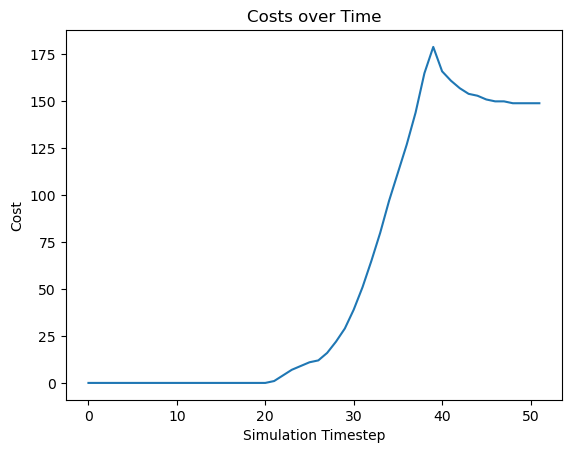

In [10]:
import matplotlib.pyplot as plt

plt.title("Costs over Time")
plt.plot(costs)
plt.ylabel("Cost")
plt.xlabel("Simulation Timestep")